In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import sys
sys.path.insert(1, '../Utilities/')

In [2]:
from sampling import *

In [3]:
from AutoDiff import *
from pinns_weights import *
from utils import *
from Trainer import Trainer

In [4]:
from PINNs import Stefan_pinn

In [5]:
import scienceplots
plt.style.use(['science', 'ieee'])

In [6]:
savefile = "outputs_2D1/"
save = True

## Params

In [7]:
Ste = 0.5
Fo = 0.01
Th = 1.
Tc = -0.5
delta = 0.05
ti = 0.05
tf = 1.

## Ref. Solution

In [8]:
file1 = '../Utilities/Ref/ref1D_0.5'
file2 = '../Utilities/Ref/ref1D_0.005'
validation_data1 = np.loadtxt(file1, delimiter=",")
validation_data2 = np.loadtxt(file2, delimiter=",")

In [9]:
if Ste == 0.5:
    file = file1
    validation_data = validation_data1
elif Ste == 0.005:
    file = file2
    validation_data = validation_data2
of = open(file)
of.readlines()[0]

'# Ste=0.500000, Fo=0.010000, delta=0.050000, nx=251, nt=100\n'

In [10]:
#nx = 201
nx = 251
nt = 101

In [11]:
t, x, u_ref = np.hsplit(validation_data, 3)
t = t.reshape(-1, nx)
x = x.reshape(-1, nx)
u_ref = u_ref.reshape(-1, nx)

times = t[:, 0]
x = x[0, :]

In [12]:
x_grid, y_grid = np.meshgrid(x, x)
T_ref = []
for i, t in enumerate(times):
    ref, _ = np.meshgrid(u_ref[i], u_ref[i])
    T_ref.append(ref)

In [13]:
# validation data for 2D case:

validation_data_2D = list()

for tk, Tk in zip(times[::5], T_ref[::5]):
    
    t = tk* np.ones_like(x_grid[::8, ::8])
    sol = np.hstack([
        t.reshape(-1, 1),
        x_grid[::8, ::8].reshape(-1, 1),
        y_grid[::8, ::8].reshape(-1, 1),
        Tk[::8, ::8].reshape(-1, 1)]
    )
    validation_data_2D.append(sol)
    
validation_data_2D = np.vstack(validation_data_2D)
print(validation_data_2D.shape)

(21504, 4)


In [14]:
levels = np.linspace(-0.5, 1., 10)
cmap='coolwarm'

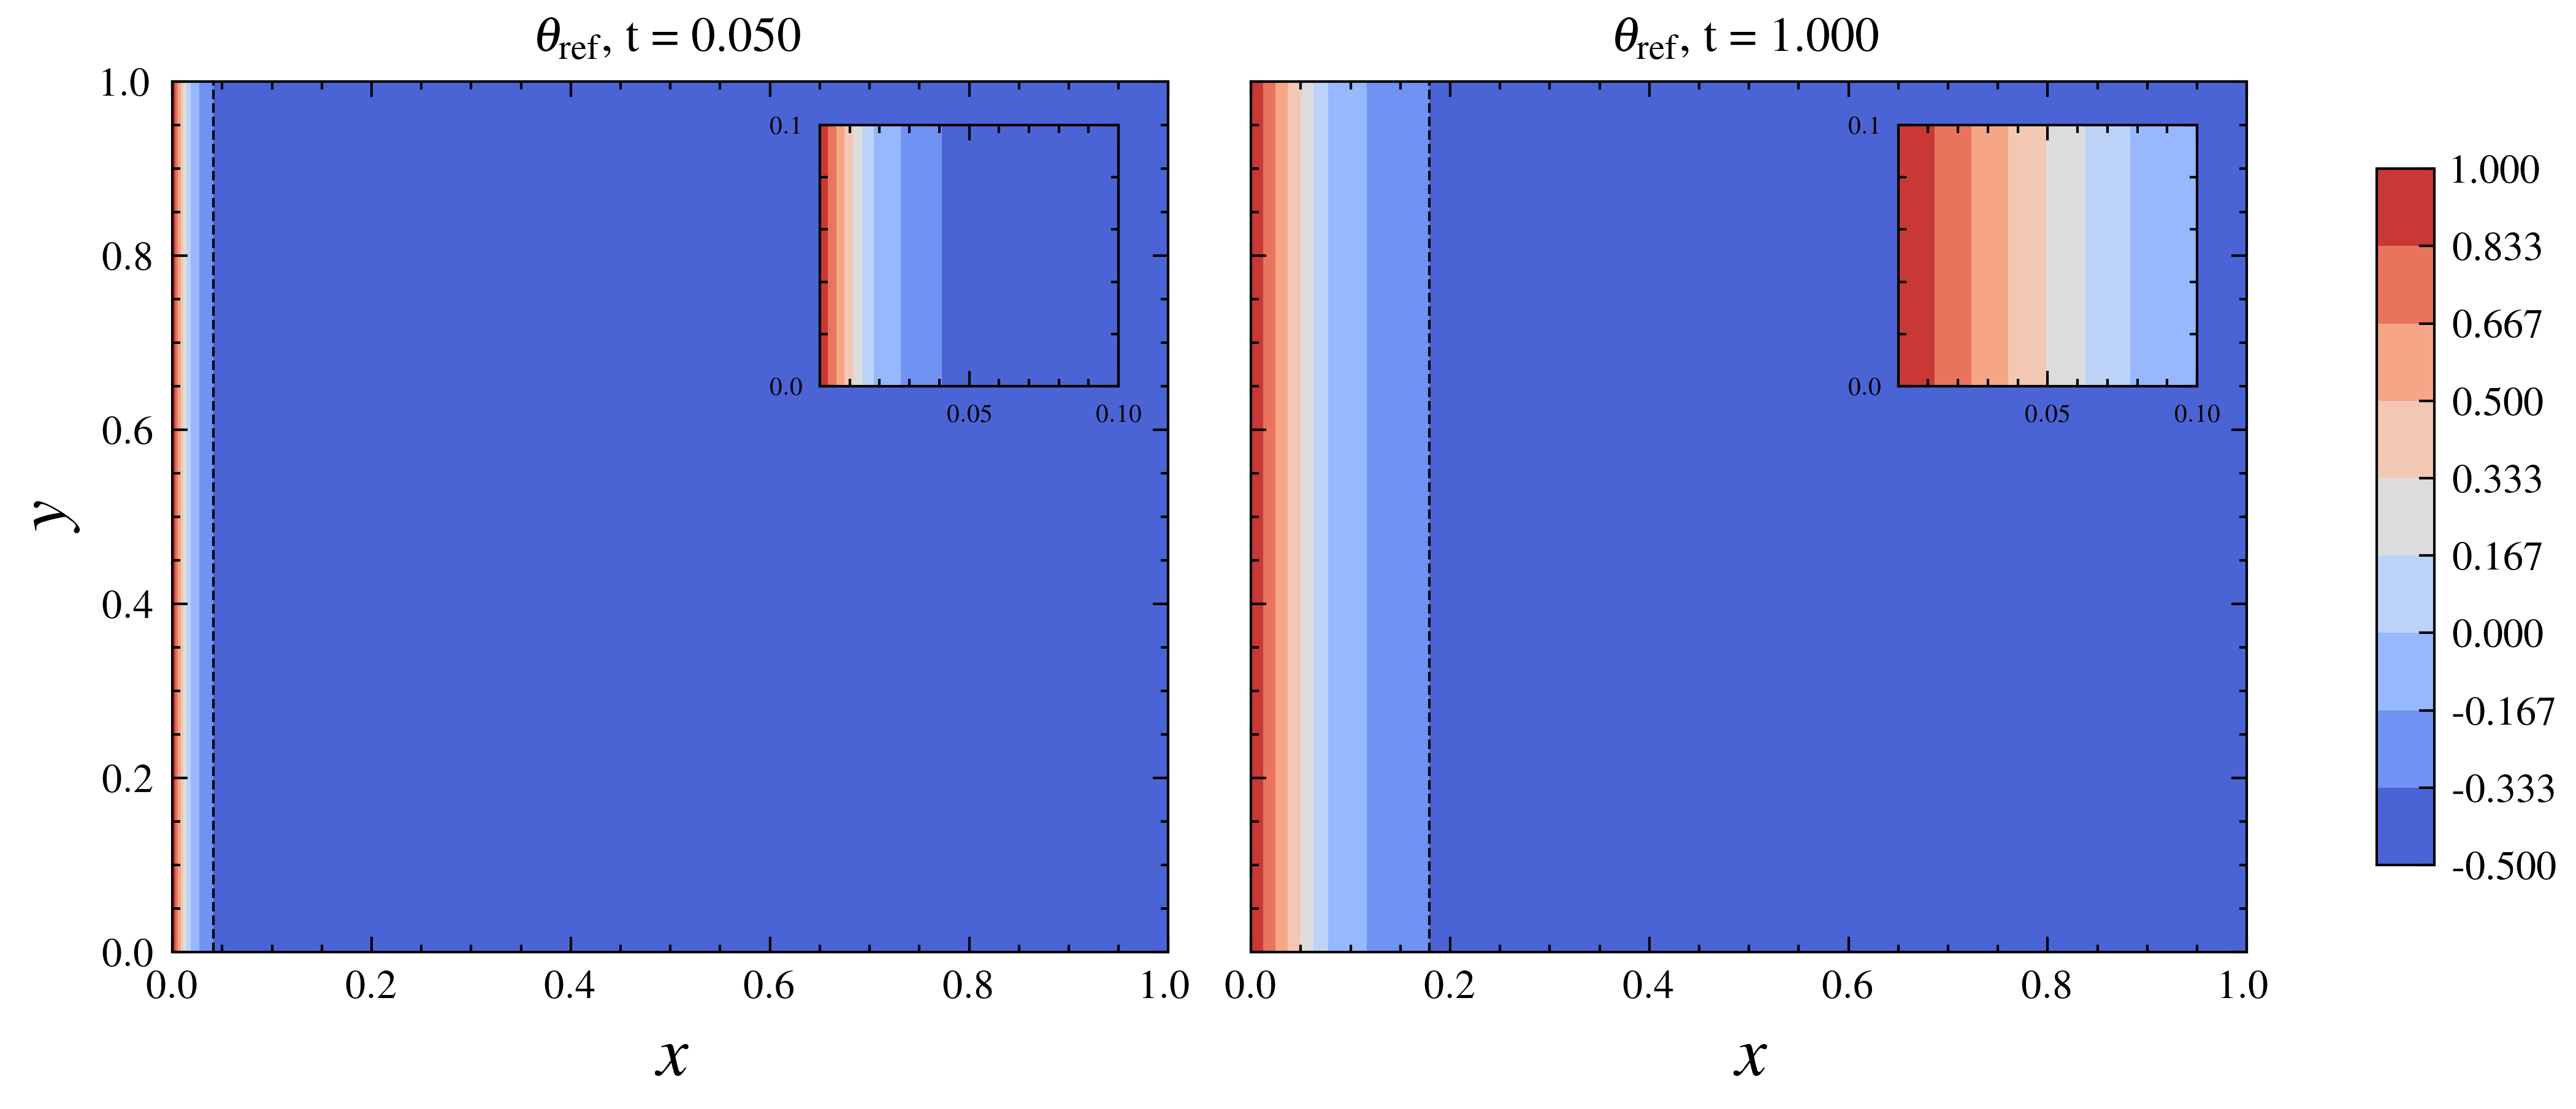

In [15]:
fig, axs = plt.subplots(1, 2, figsize=(7, 3), constrained_layout=True, sharey=True)

i = 0
j = -1

ctf = axs[0].contourf(x_grid, y_grid, T_ref[i], levels, cmap=cmap)
ct = axs[0].contour(x_grid, y_grid, T_ref[i], levels=[levels[1]], colors='black', linewidths=0.5)

ctf = axs[1].contourf(x_grid, y_grid, T_ref[j], levels, cmap=cmap)
ct = axs[1].contour(x_grid, y_grid, T_ref[j], levels=[levels[1]], colors='black', linewidths=0.5)

cb = fig.colorbar(ctf, shrink=.8, aspect=12, ax = axs[:], format='%.3f')

axs[0].set_title(r"$\theta_\mathrm{ref}$, t = %.3f"%(times[i]))
axs[1].set_title(r"$\theta_\mathrm{ref}$, t = %.3f"%(times[j]))


x1, x2, y1, y2 = 0., 0.1, 0., 0.1
for i in [0, -1]:
    axins = axs[i].inset_axes([0.65, 0.65, 0.3, 0.3], xticks=[0.05, 0.1], yticks=[0, 0.1])
    axins.contourf(x_grid, y_grid, T_ref[i], levels, cmap=cmap)
    axins.tick_params(labelsize=5)
    axins.set_xlim(x1, x2)
    axins.set_ylim(y1, y2)

axs[0].set_ylabel('$y$', fontsize = 14)
axs[0].set_xlabel('$x$', fontsize = 14)
axs[1].set_xlabel('$x$', fontsize = 14)

if save:
    plt.savefig(savefile+"2D1_ref.pdf")
    plt.savefig(savefile+"2D1_ref.png")
plt.show()

In [16]:
class stefan_problem(Trainer):
    
    def __init__(self, model, 
                 ics_sampler, bcs_sampler, res_sampler,
                 n_ics, n_bcs, n_res,
                 validation_data = None):
        super().__init__(model, validation_data)
        *self.ics_in, self.ics_out = ics_sampler.sample(n_ics, device=self.device)
        *self.bcs1_in, self.bcs1_out = bcs_sampler[0].sample(n_bcs, device=self.device)
        *self.bcs2_in, self.bcs2_out = bcs_sampler[1].sample(n_bcs, device=self.device)
        *self.res_in, _= res_sampler.sample(n_res, device=self.device)
        self.res_sampler = res_sampler
        self.validation_data_is_available = False
        if validation_data is not None:
            if not torch.is_tensor(validation_data):
                validation_data = torch.Tensor(validation_data).to(self.device)
            *self.val_in, self.val_out = np.split(validation_data, 4, 1)
            self.validation_data_is_available = True
            
        self.weights_dict = {'ics': [], 'bcs': [], 'res': []}
        self.losses_dict = {'ics': [], 'bcs': [], 'res': [], 'total':[], 'l2': []}
        
    def loss_fn(self):
        # initial conditions
        ics = self.net(*self.ics_in)
        ics_mse, ics_error = self.mse_error(ics, self.ics_out)
        
        # Dirichlet boundary conditions
        bcs1 = self.net(*self.bcs1_in)
        bcs1_mse, bcs1_error = self.mse_error(bcs1, self.bcs1_out)
        
        # Neumann boundary conditions
        _ , _, Ty = self.net_grad(*self.bcs2_in)
        n1 = torch.where(self.bcs2_in[2]==0., 1., 0.) # 1. where y==0., zero otherwise
        n2 = torch.where(self.bcs2_in[2]==1., 1., 0.) # 1. where y==1., zero otherwise
        bcs21_mse, bcs21_error = self.mse_error(Ty* n1)
        bcs22_mse, bcs22_error = self.mse_error(Ty* n2)
        bcs2_mse = bcs21_mse + bcs22_mse
        # PDE
        res = self.net_res(*self.res_in)
        res_mse, res_error = self.mse_error(res)
        
        losses = (ics_mse, bcs1_mse + bcs2_mse, res_mse)
        errors = (ics_error, bcs1_error, bcs21_error, bcs22_error, res_error)
        return losses, errors

    
    def train(self, num_epochs, weighting_dict, optim_dict, l2_frequency=1000):
        
        weighting_dict = self._set_weights(weighting_dict)
        self._set_opt(weighting_dict, optim_dict)

        epochs = tqdm(range(num_epochs))
        for epoch in epochs:
            
            """ To Do
            if adaptive:
                if epoch !=0 and epoch % 100 == 0:
                    *self.res_in, _ , res_weights = self.res_sampler._update(self.res_in, save=True)
            """
            
            closure = lambda: self.closure_fn(epoch, weighting_dict)
            loss = self.step(closure)

            # Save losses and weights
            for i, (ll, wl) in enumerate(zip(self.losses_dict.values(), self.weights_dict.values())):
                ll.append(self._last_losses[i])
                wl.append(self.loss_weights[i])
            self.losses_dict["total"].append(loss.item())
            
            epochs.set_description('total loss : %.2e' %(loss.item()))
            if self.validation_data_is_available and (epoch % l2_frequency)==0:
                self.validation_error(epoch)

In [18]:
layers = [3] + 6* [20] + [1]
activations = "Tanh"

In [33]:
model = Stefan_pinn(layers, activations, Ste, Fo, delta, dim=2, seed=456)

### Samplers

In [34]:
xl, xu = 0., 1.
yl, yu = 0., 1.

ones = lambda *args: np.ones_like(args[0])

bc1_sampler = Sampler([ti, xl, yl], [tf, xl, yu], lambda *args: Th*ones(*args)) # at xl
bc2_sampler = Sampler([ti, xu, yl], [tf, xu, yu], lambda *args: Tc*ones(*args)) # at xu
bc3_sampler = Sampler([ti, xl, yl], [tf, xu, yl]) # at yl
bc4_sampler = Sampler([ti, xl, yu], [tf, xu, yu]) # at yu

bcs1_sampler = Join_samplers([bc1_sampler, bc2_sampler])
bcs2_sampler = Join_samplers([bc3_sampler, bc4_sampler])
bcs_sampler = [bcs1_sampler, bcs2_sampler]

In [35]:
def adapt(j, pas1=2, pas2=25):
    i = list(range(j)[::pas1]) + list(range(j, nx)[::pas2])
    i[-1] = nx - 1
    return np.meshgrid(i, i)

In [36]:
i, j = adapt(25, pas1=1) 
j = np.linspace(0, nx-1, len(i), dtype=int)
_, j = np.meshgrid(j, j) 

"""
plt.scatter(x_grid[j, i], y_grid[j, i], s=.5)
plt.show()
""";

In [37]:
x0 = x_grid[j, i]
y0 = y_grid[j, i]
t0 = 0.05* np.ones_like(x0)
T0 = T_ref[0][j, i]

ics = np.hstack([
    t0.reshape(-1, 1),
    x0.reshape(-1, 1),
    y0.reshape(-1, 1),
    T0.reshape(-1, 1)
])
ics_sampler = data_sampler(ics)

In [38]:
n_ics = ics_sampler.n
n_ics

1225

In [39]:
t0, x0, y0, T0 = ics_sampler.sample(n_ics)
t0 = t0.cpu().numpy()
x0 = x0.cpu().numpy().flatten()
y0 = y0.cpu().numpy().flatten()
T0 = T0.cpu().numpy().flatten()

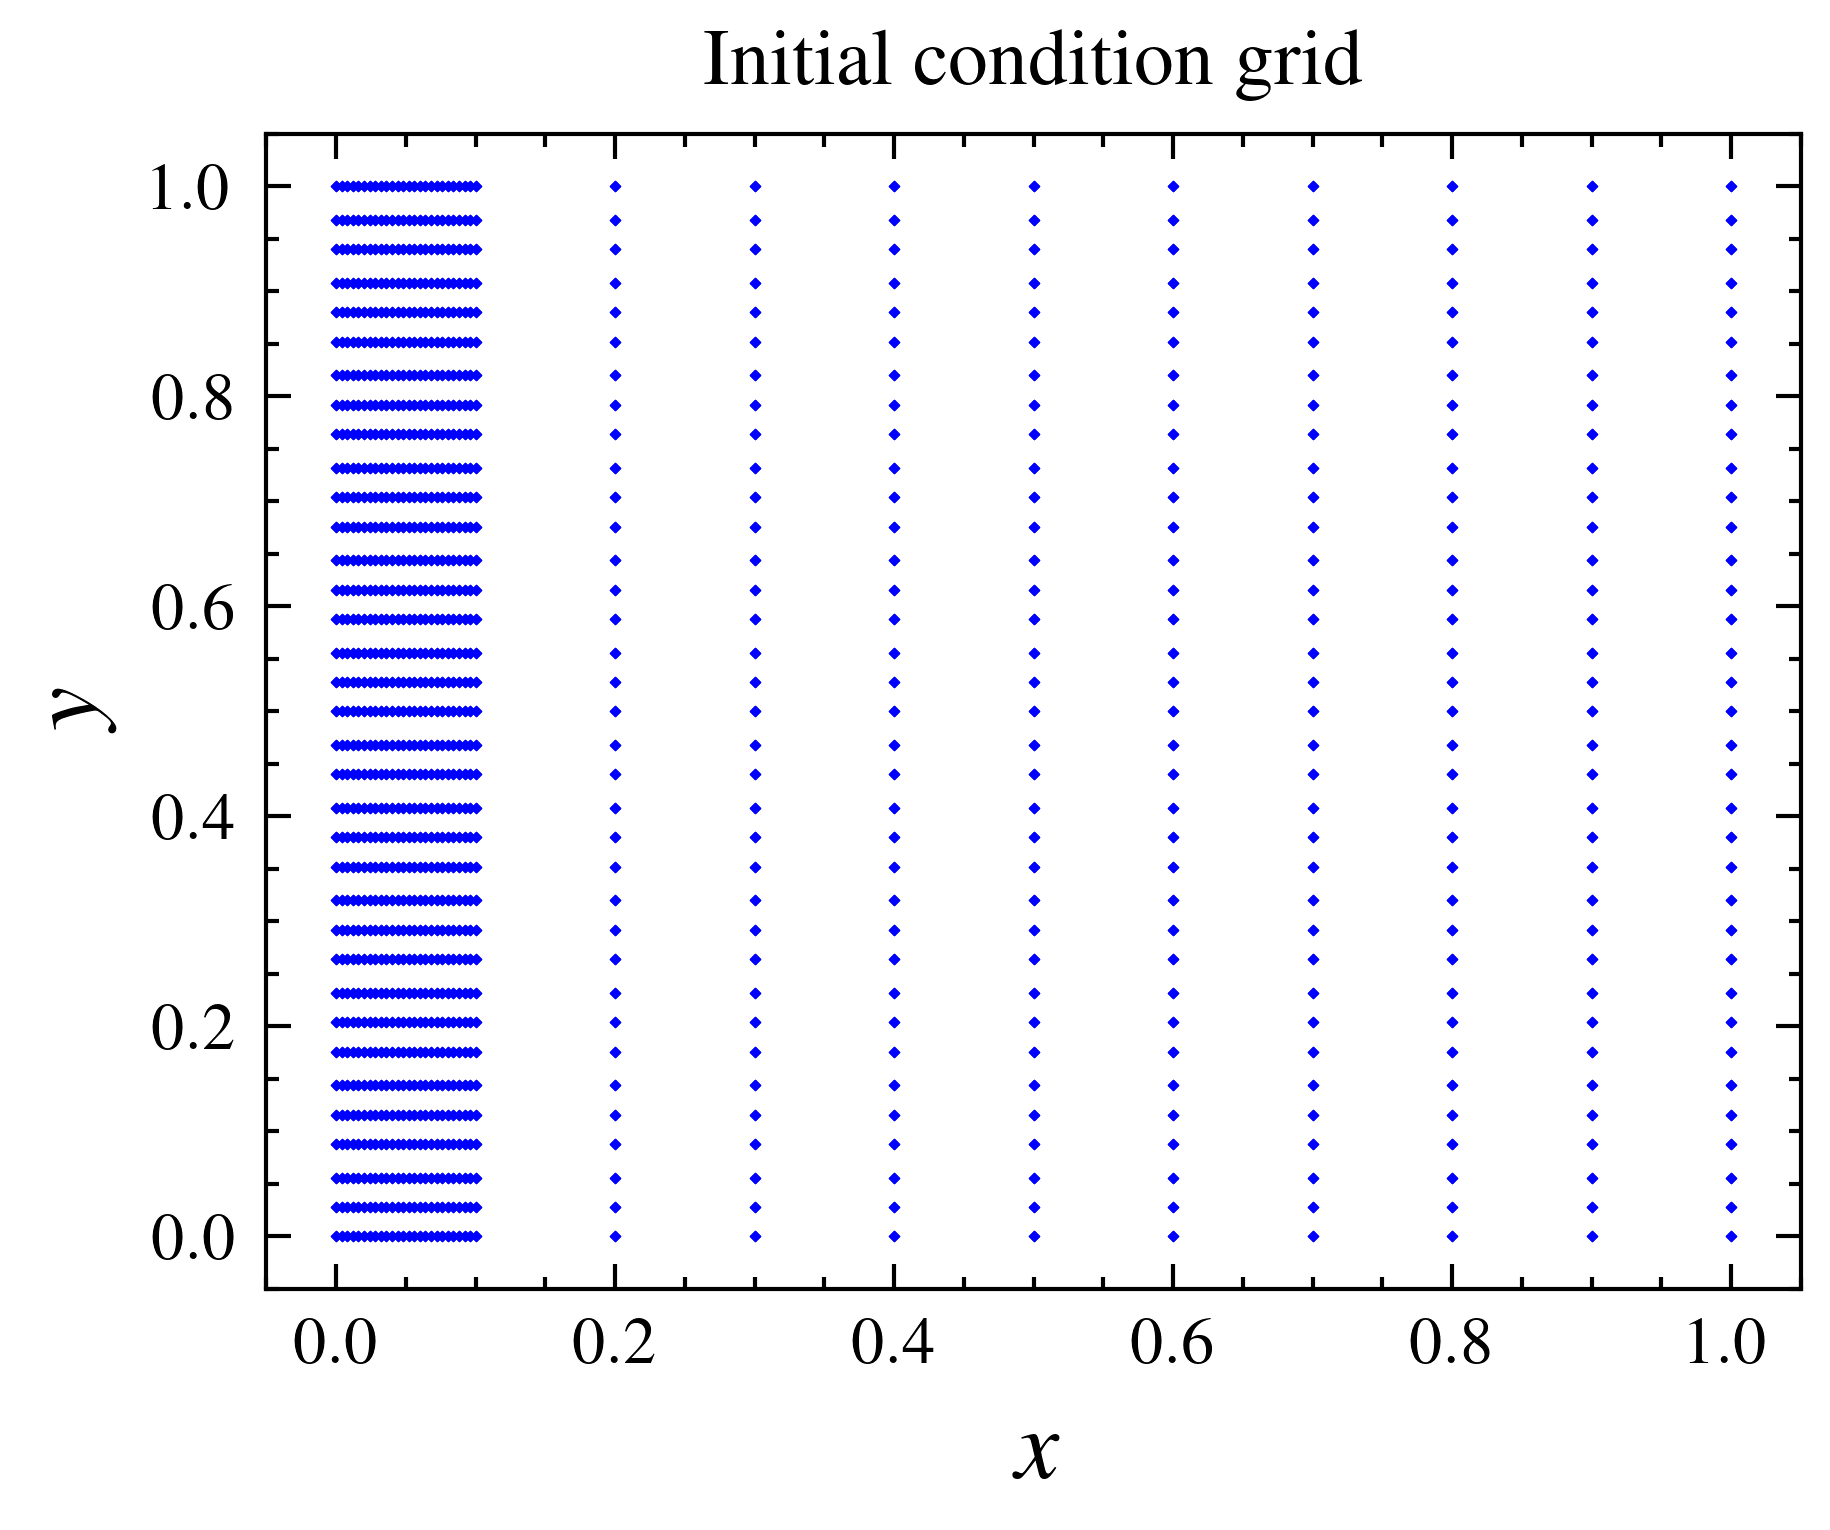

In [40]:
fig, ax = plt.subplots(1, 1)

#cb = ax.tricontourf(x0, y0, T0, cmap="coolwarm")
#fig.colorbar(cb)

ax.scatter(x0, y0, c='b', s=.5, marker="x")
#plt.xlim(-0.001, 1.0001)

ax.set_title("Initial condition grid")
ax.set_xlabel("$x$", fontsize=12)
ax.set_ylabel("$y$", fontsize=12)

plt.savefig(savefile+"grid.pdf", bbox_inches ='tight')
plt.savefig(savefile+"grid.png", bbox_inches ='tight')
plt.show()

In [41]:
res_sampler = Sampler(
    l_bounds=[ti, xl, yl],
    u_bounds=[tf, xu, yu],
)

In [42]:
n_bcs = 2* 256
n_res = 8000

### Trainer

In [43]:
stefan_trainer = stefan_problem(
    model, 
    ics_sampler, bcs_sampler, res_sampler, 
    n_ics, n_bcs, n_res,
    validation_data=validation_data_2D
)

### L-BFGS

In [44]:
weighting_dict = {
    "method": None,
    "weights": [100., 50., 1.]
}

In [45]:
optim_dict = dict(
    optimizer="LBFGS",
    max_iter=50,
    line_search_fn="strong_wolfe",
    history_size=100,
    tolerance_grad=1e-7
)

l2_frequency = 1

In [46]:
%%time

n_epochs = 101
stefan_trainer.train(
    n_epochs, 
    optim_dict=optim_dict,
    weighting_dict=weighting_dict,
    l2_frequency=1
)

  0%|          | 0/101 [00:00<?, ?it/s]

CPU times: user 1min 12s, sys: 332 ms, total: 1min 12s
Wall time: 1min 13s


### Save:

In [31]:
if save:
    model.save(file=savefile)
    stefan_trainer.save(file=savefile, weights=True)

### Losses:

In [59]:
losses = stefan_trainer.losses_dict
l2_ep = range(n_epochs)[::l2_frequency]

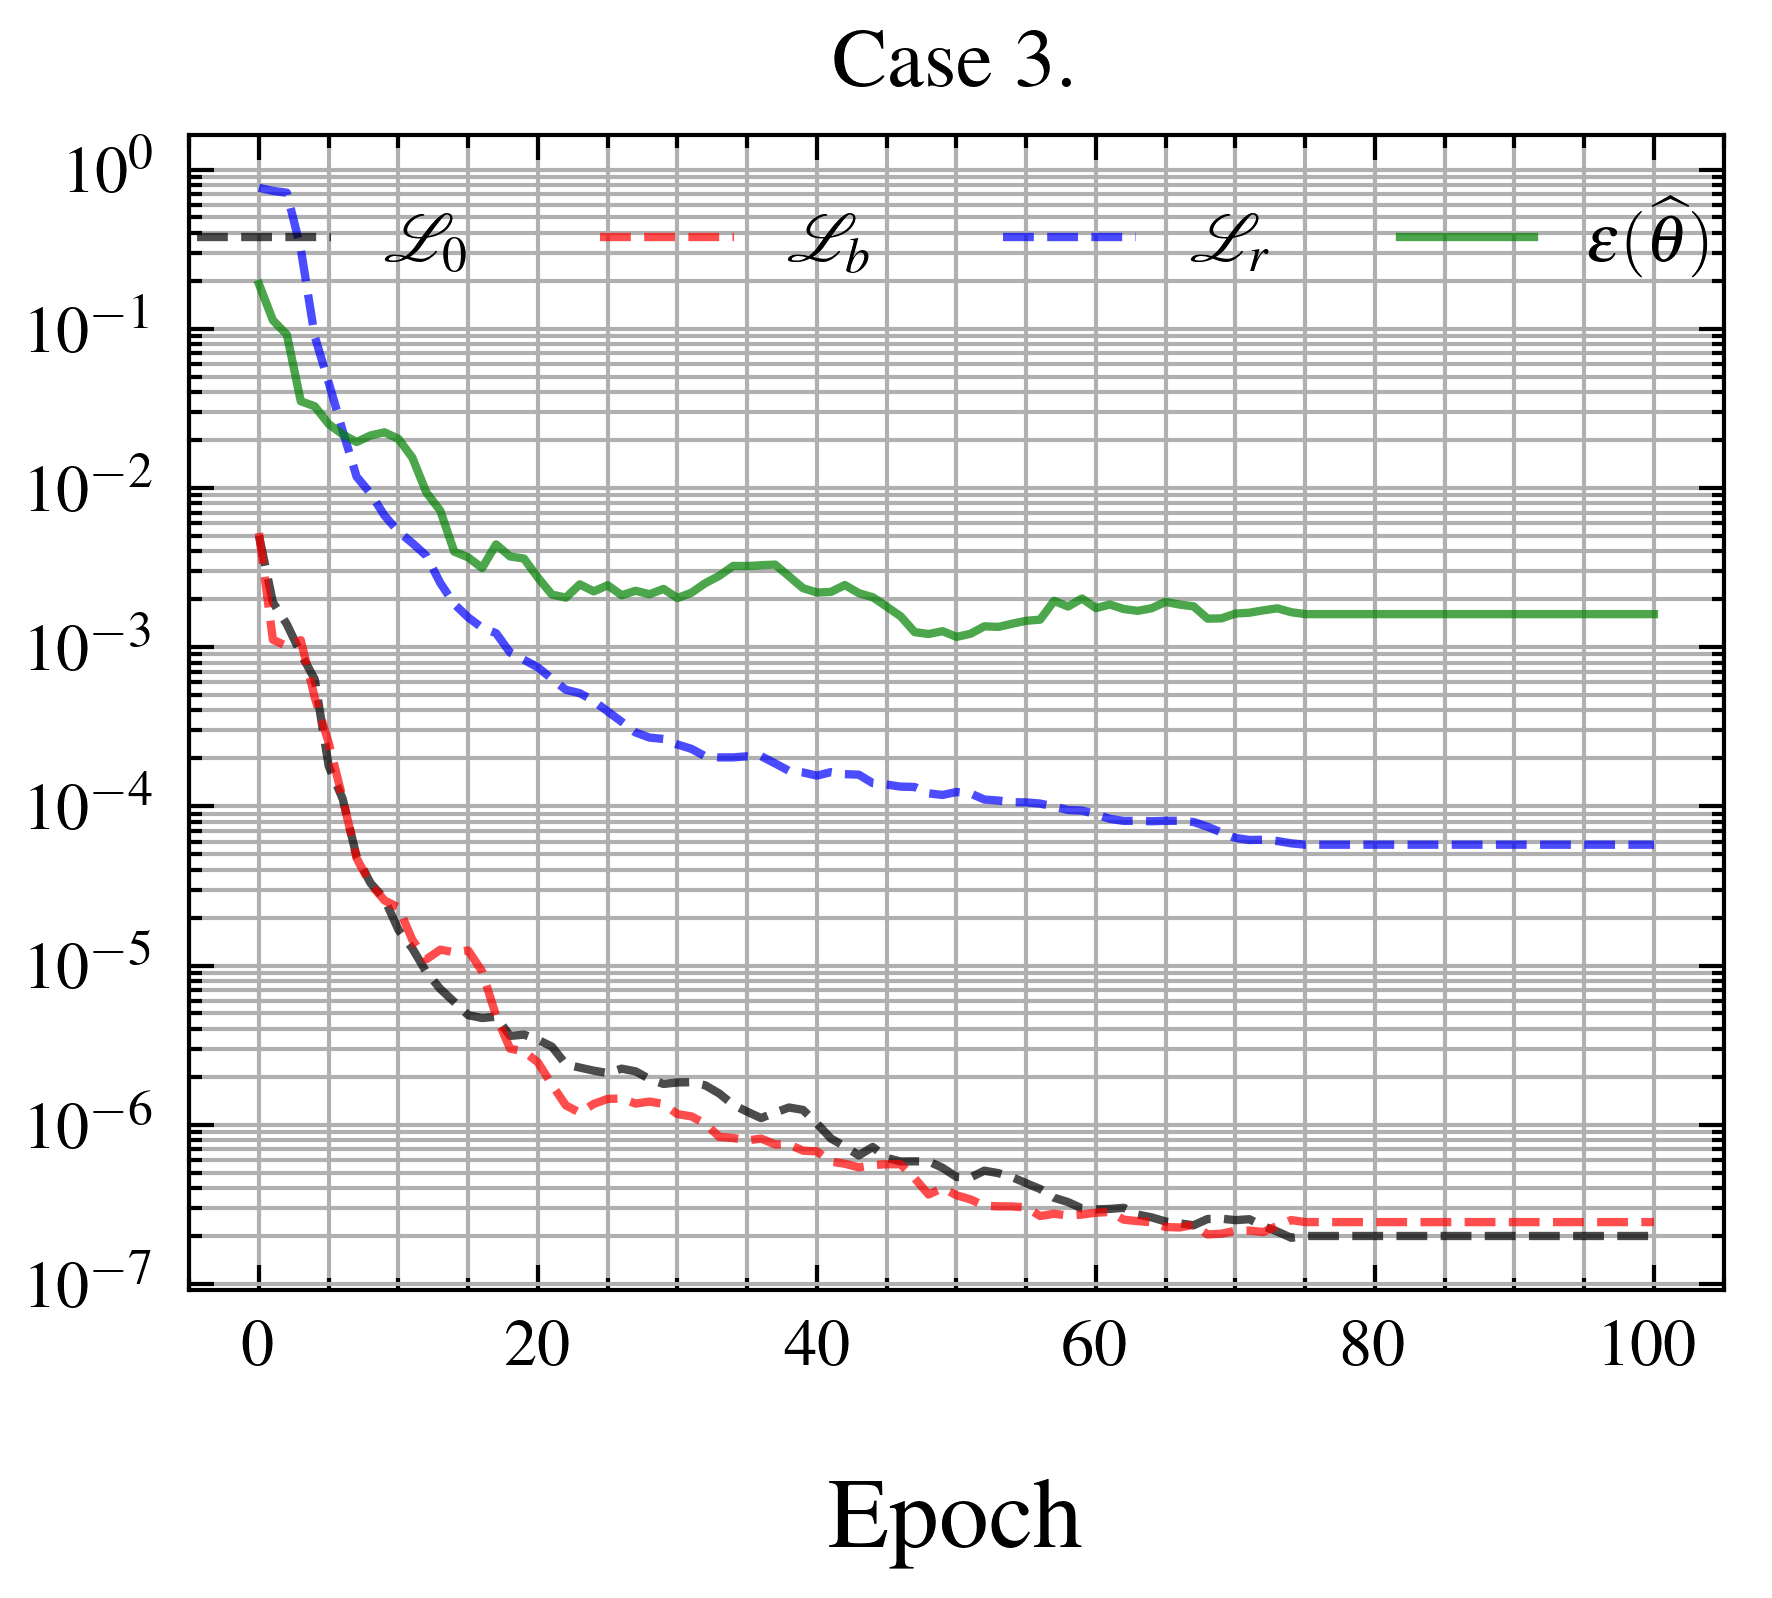

In [61]:
fig, ax = plt.subplots(1, 1)

ax.plot(losses['ics'], '--', label='$\mathcal{L}_{0}$', alpha=.7)
ax.plot(losses['bcs'], '--', label='$\mathcal{L}_{b}$', alpha=.7)
ax.plot(losses['res'], '--', label='$\mathcal{L}_{r}$', alpha=.7)
ax.plot(l2_ep, losses['l2'], '-', label=r'$\epsilon(\widehat\theta)$', alpha=.7)

ax.grid(True, "both")
ax.set_yscale('log')
ax.set_xlabel('Epoch', fontsize = 12, labelpad=12)
#ax.set_ylabel('Loss', fontsize = 12, labelpad=12)
ax.set_title('Case 3.', fontsize = 10)

#ax.ticklabel_format(style='sci', axis='x', scilimits=(3, 3))
ax.legend(loc="upper center", ncol=4)

if save:
    plt.savefig(savefile + 'losses.pdf', bbox_inches ='tight')
plt.show()

In [62]:
try:
    print(f"l2 error: {losses['l2'][-1]: .3e}")
    print(f"min l2 error: {min(losses['l2']): .3e}")
except: pass

l2 error:  1.611e-03
min l2 error:  1.160e-03


### Weights:

In [63]:
weights = stefan_trainer.weights_dict
every = 1
weights_ep = range(n_epochs)[::every]

100.0 50.0 1.0


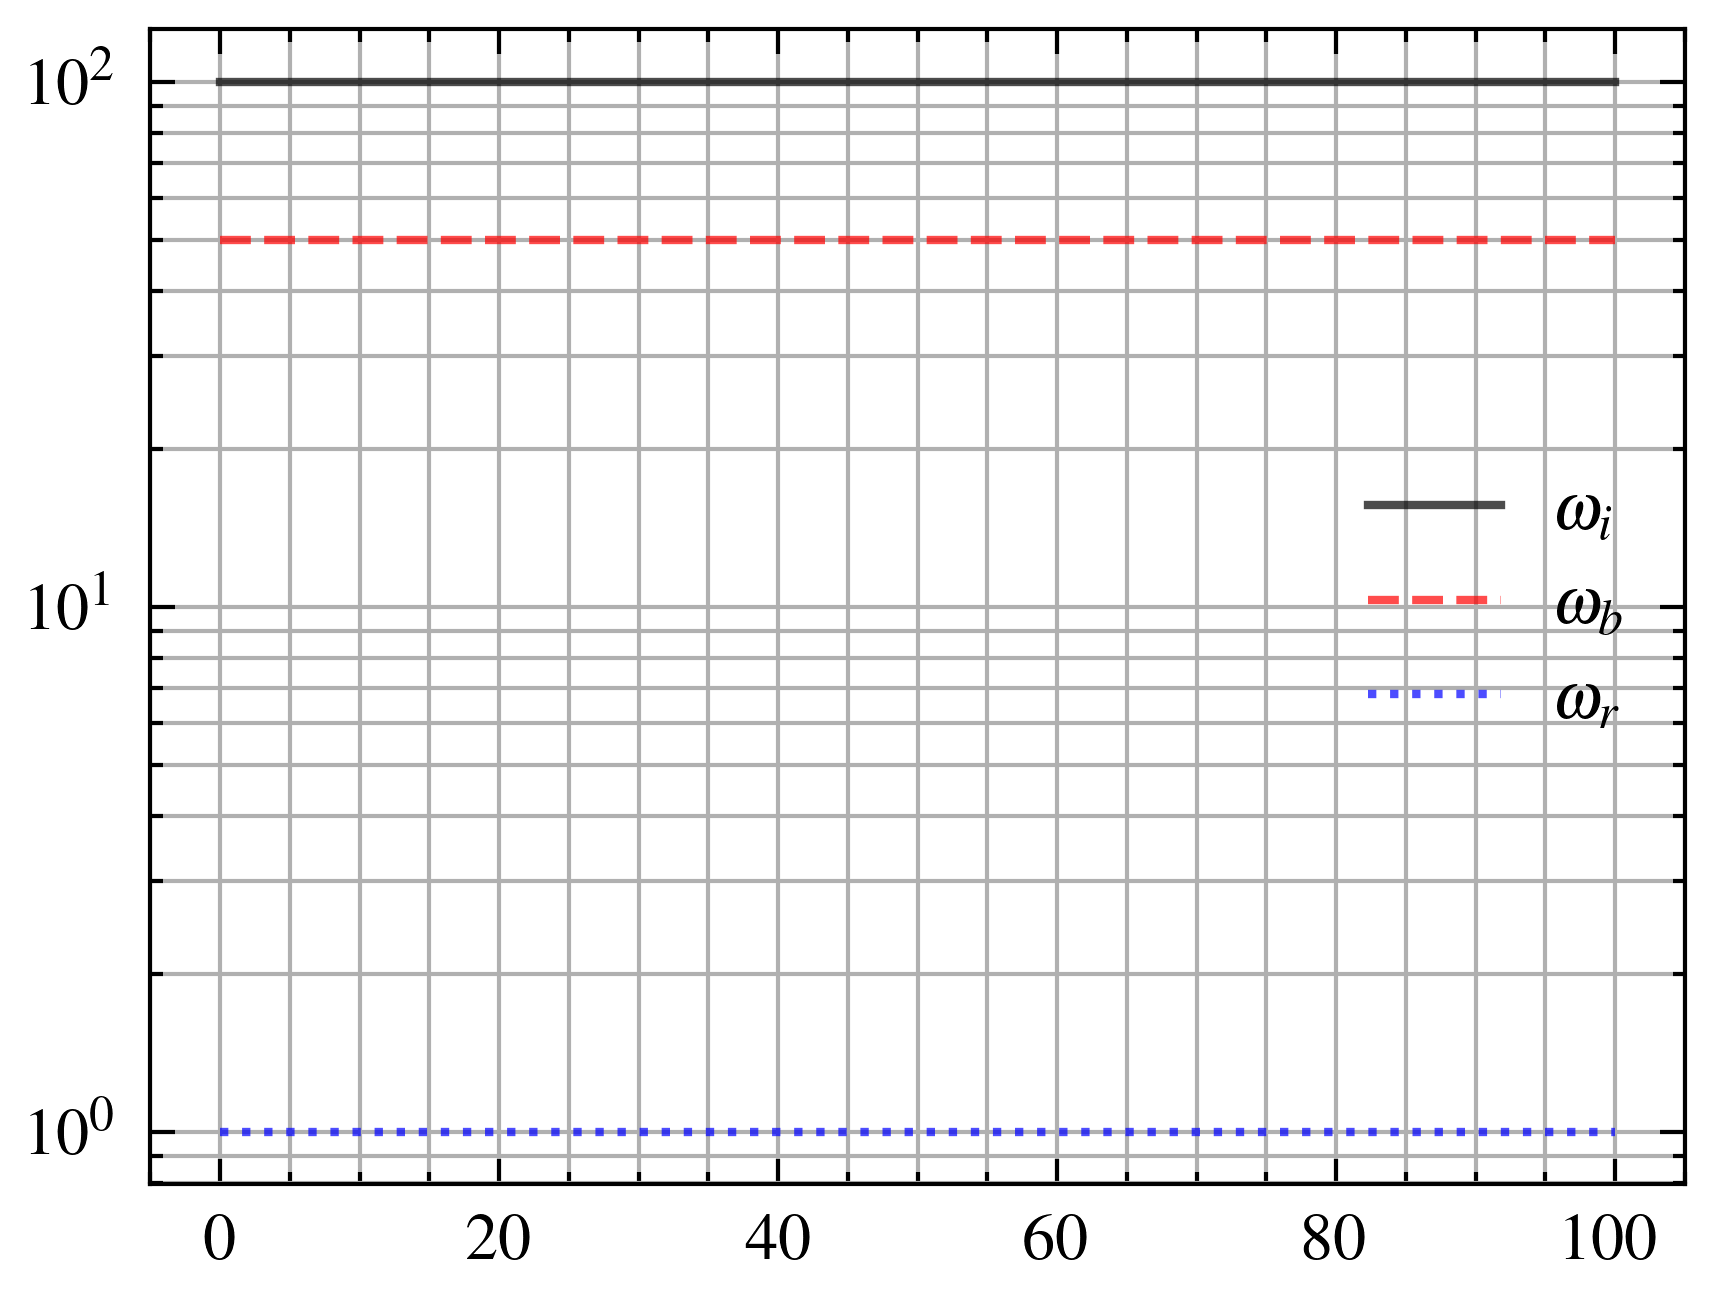

In [64]:
print(np.mean(weights['ics']), np.mean(weights['bcs']), np.mean(weights['res']))

plt.grid(True, which='both')
plt.yscale('log')

plt.plot(weights['ics'][::every], label='$\omega_i$', alpha=.7)
plt.plot(weights['bcs'][::every], label='$\omega_b$', alpha=.7)
plt.plot(weights['res'][::every], label='$\omega_r$', alpha=.7)

plt.legend()


if save:
    plt.savefig(file +'weights.pdf', bbox_inches ='tight')
plt.show()

### Solution:

In [65]:
def pred(t):
    return model.evaluate(
        t* ones(x_grid.reshape(-1, 1)),
        x_grid.reshape(-1, 1),
        y_grid.reshape(-1, 1)
    ).reshape(nx, nx)

In [66]:
T_pred = []

for i, t in enumerate(times):
    T_pred.append(pred(t))
    
x = np.diag(x_grid)
y = np.diag(y_grid)

In [67]:
i = 0
j = -1

abs_err1 = np.abs(T_ref[i] - T_pred[i])
abs_err2 = np.abs(T_ref[j] - T_pred[j])

vmin = min(abs_err1.min(), abs_err2.min())
vmax = max(abs_err1.max(), abs_err2.max())
levels = np.linspace(vmin, vmax, 10)

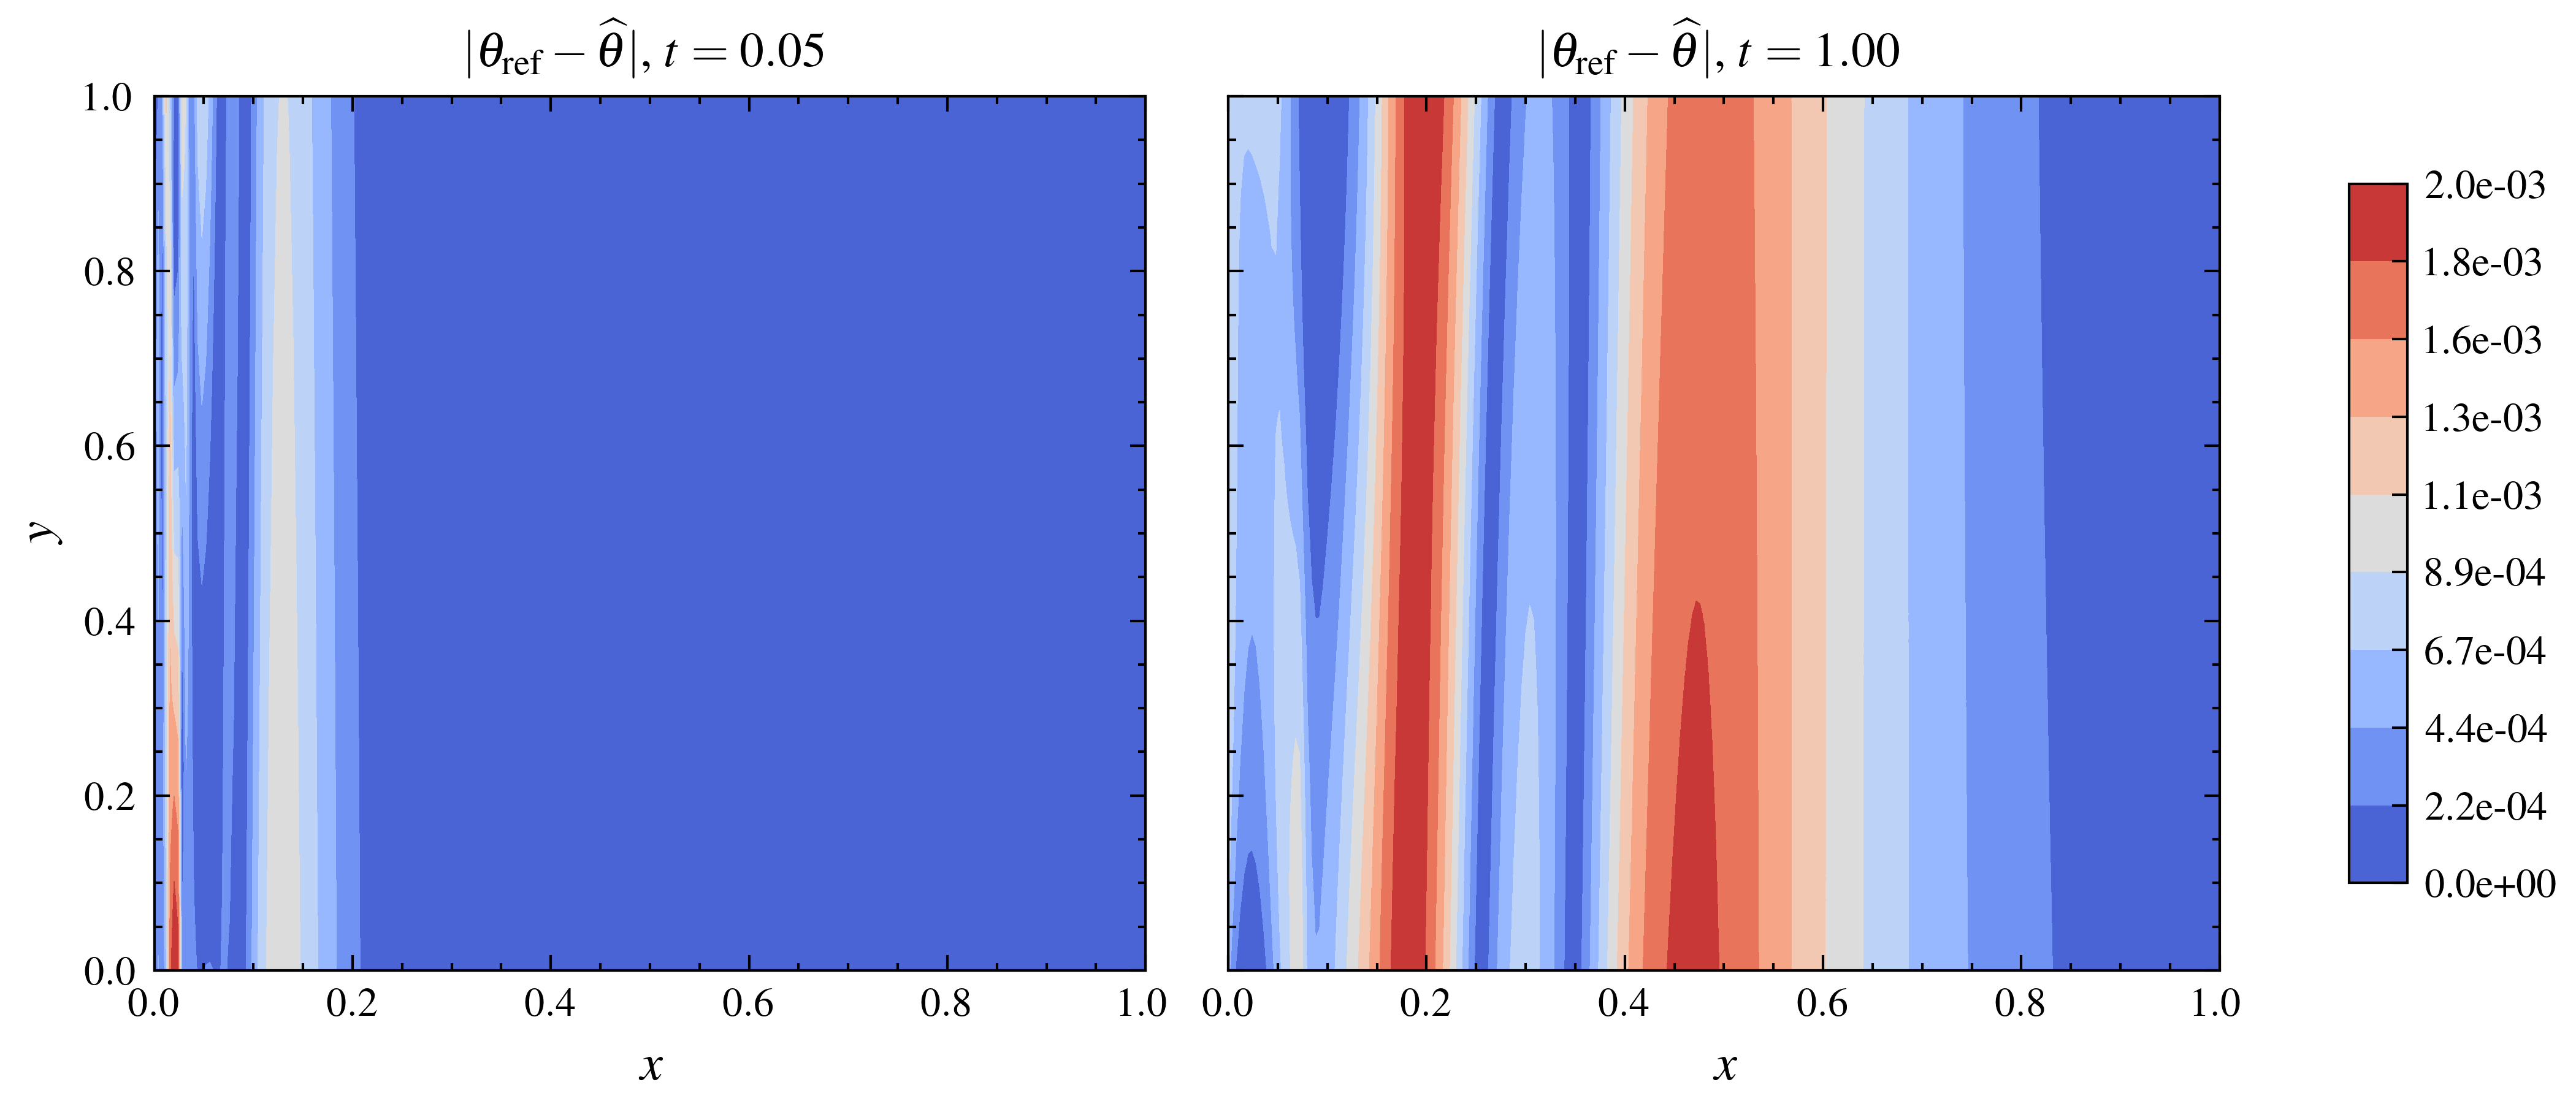

In [78]:
fig, axs = plt.subplots(1, 2, figsize=(7, 3), constrained_layout=True, sharey=True)

i = 0
j = -1

ctf = axs[0].contourf(x_grid, y_grid, abs_err1, levels=levels, cmap=cmap)
ctf = axs[1].contourf(x_grid, y_grid, abs_err2, levels=levels, cmap=cmap)
cb = fig.colorbar(ctf, shrink=.8, aspect=12, ax = axs[:], format='%.1e')

axs[0].set_title(r"$|\theta_\mathrm{ref} - \widehat\theta|$, $t = %.2f$"%(times[i]))
axs[1].set_title(r"$|\theta_\mathrm{ref} - \widehat\theta|$, $t = %.2f$"%(times[j]))

axs[0].set_ylabel('$y$', fontsize = 10)
axs[0].set_xlabel('$x$', fontsize = 10)
axs[1].set_xlabel('$x$', fontsize = 10)

if save:
    plt.savefig(savefile+"2D1_abs_error.pdf")
    plt.savefig(savefile+"2D1_abs_error.png")
plt.show()

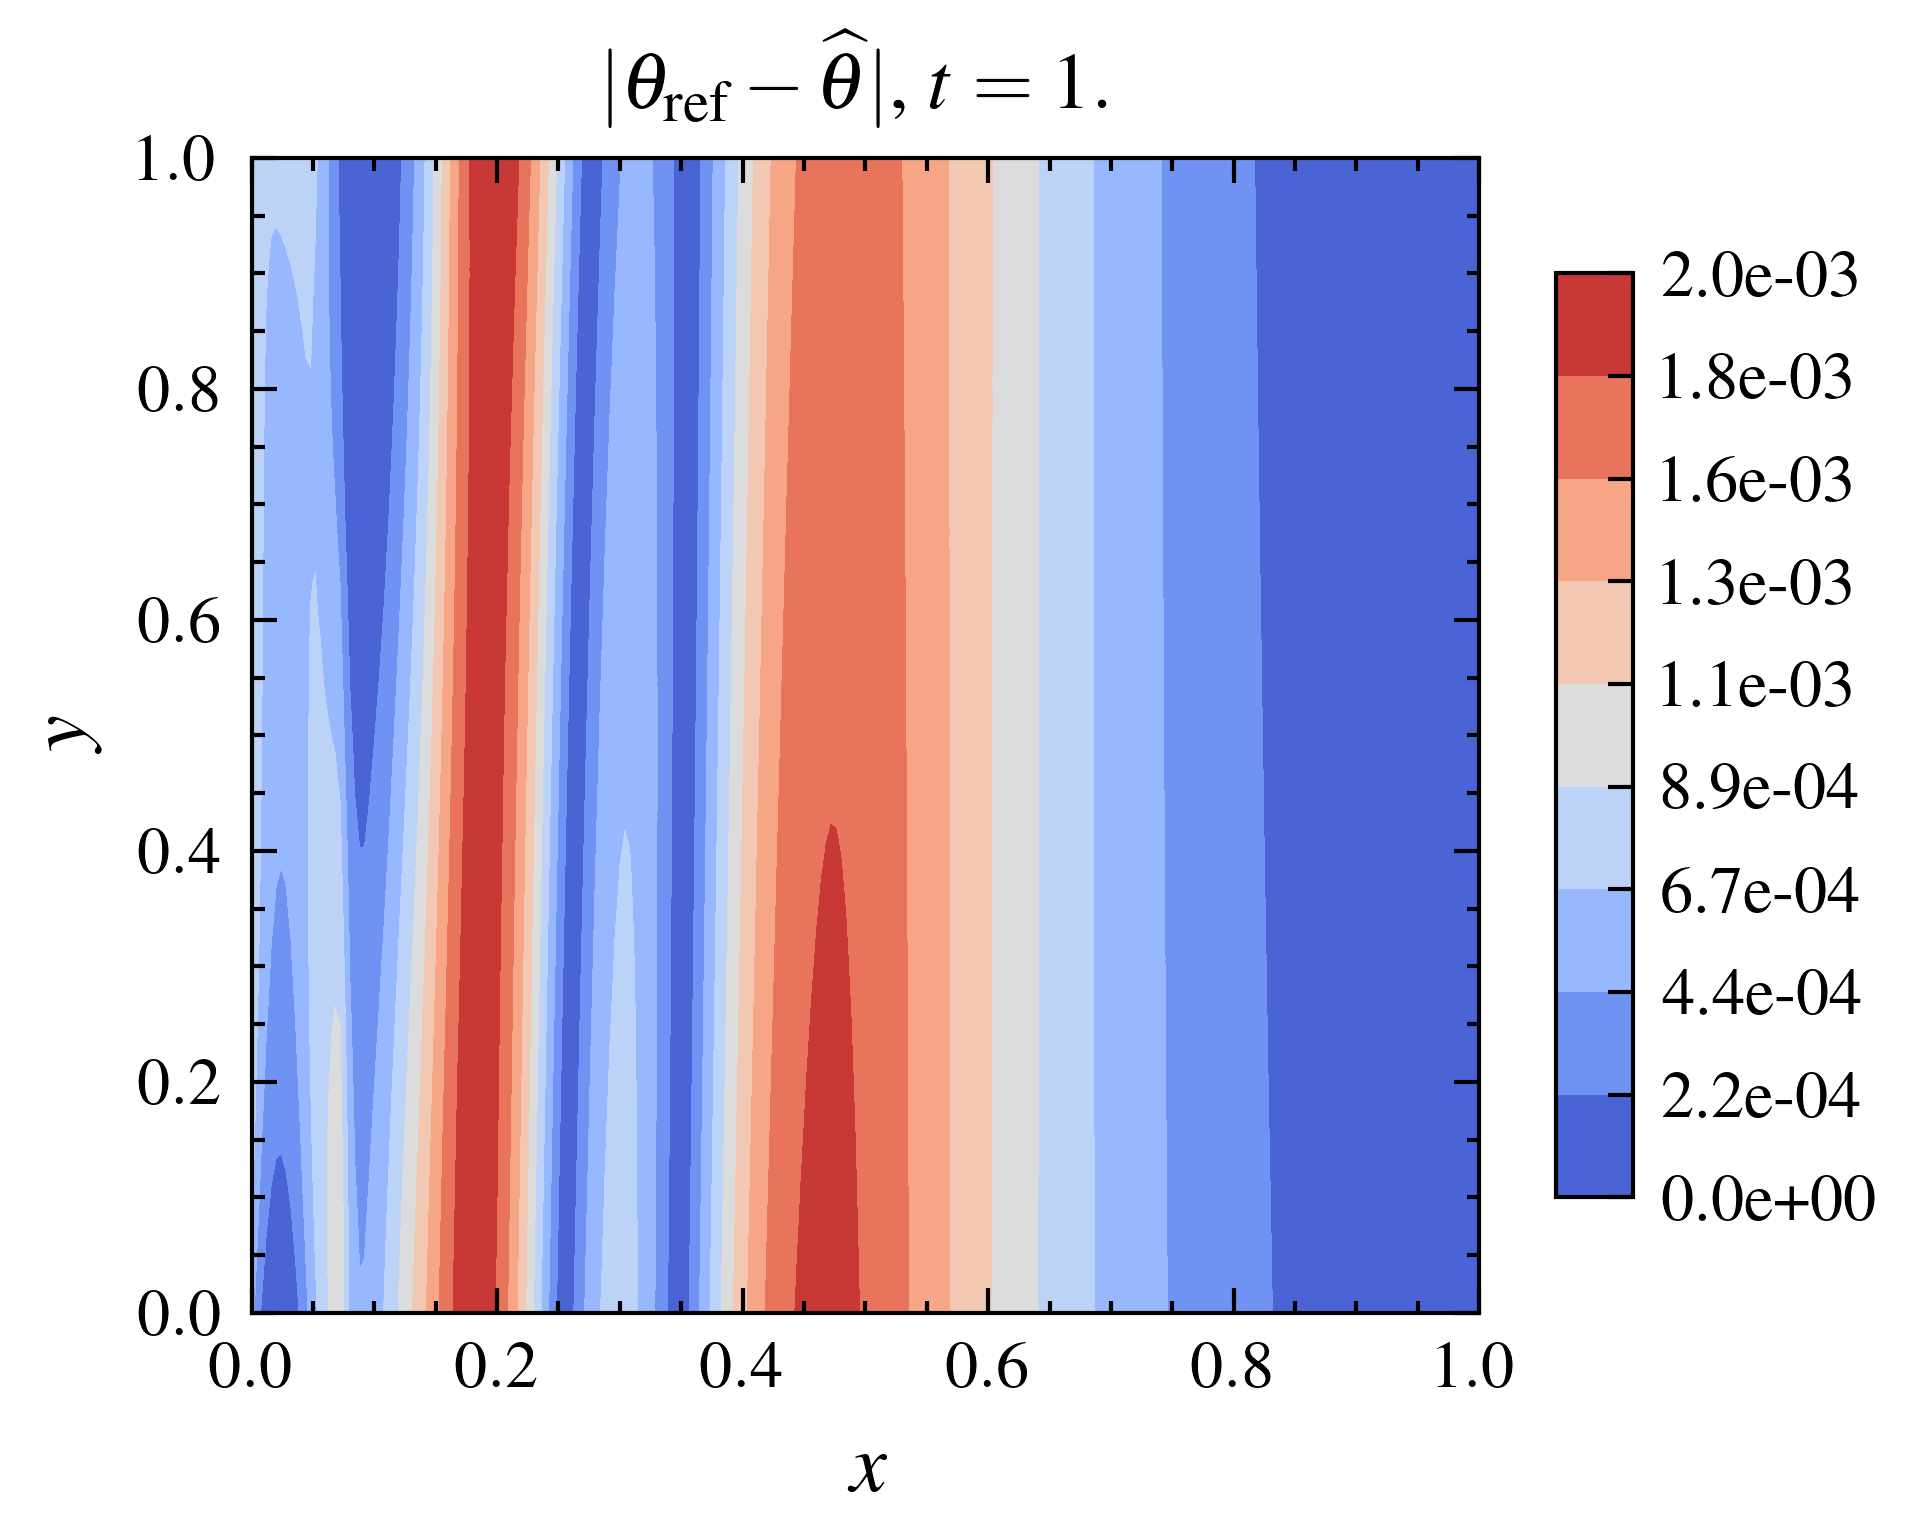

In [80]:
fig, axs = plt.subplots(1, 1)

axs = [axs]
ctf = axs[0].contourf(x_grid, y_grid, abs_err2, levels=levels, cmap=cmap)
cb = fig.colorbar(ctf, shrink=.8, aspect=12, ax = axs[:], format='%.1e')

axs[0].set_title(r"$|\theta_\mathrm{ref} - \widehat\theta|$, $t = 1.$")

axs[0].set_ylabel('$y$', fontsize = 10)
axs[0].set_xlabel('$x$', fontsize = 10)

if save:
    plt.savefig(savefile+"2D1_abs_error.pdf")
    plt.savefig(savefile+"2D1_abs_error.png")
plt.show()

In [81]:
# dT/dy

_, _, Ty = model.net_grad(
    torch.Tensor(np.ones_like(x_grid)).reshape(-1, 1).cuda(),
    torch.Tensor(x_grid).reshape(-1, 1).cuda(),
    torch.Tensor(y_grid).reshape(-1, 1).cuda(),
)

In [51]:
Ty = Ty.detach().cpu().reshape(nx, nx)
levels = np.linspace(0, np.abs(Ty).max(), 10)

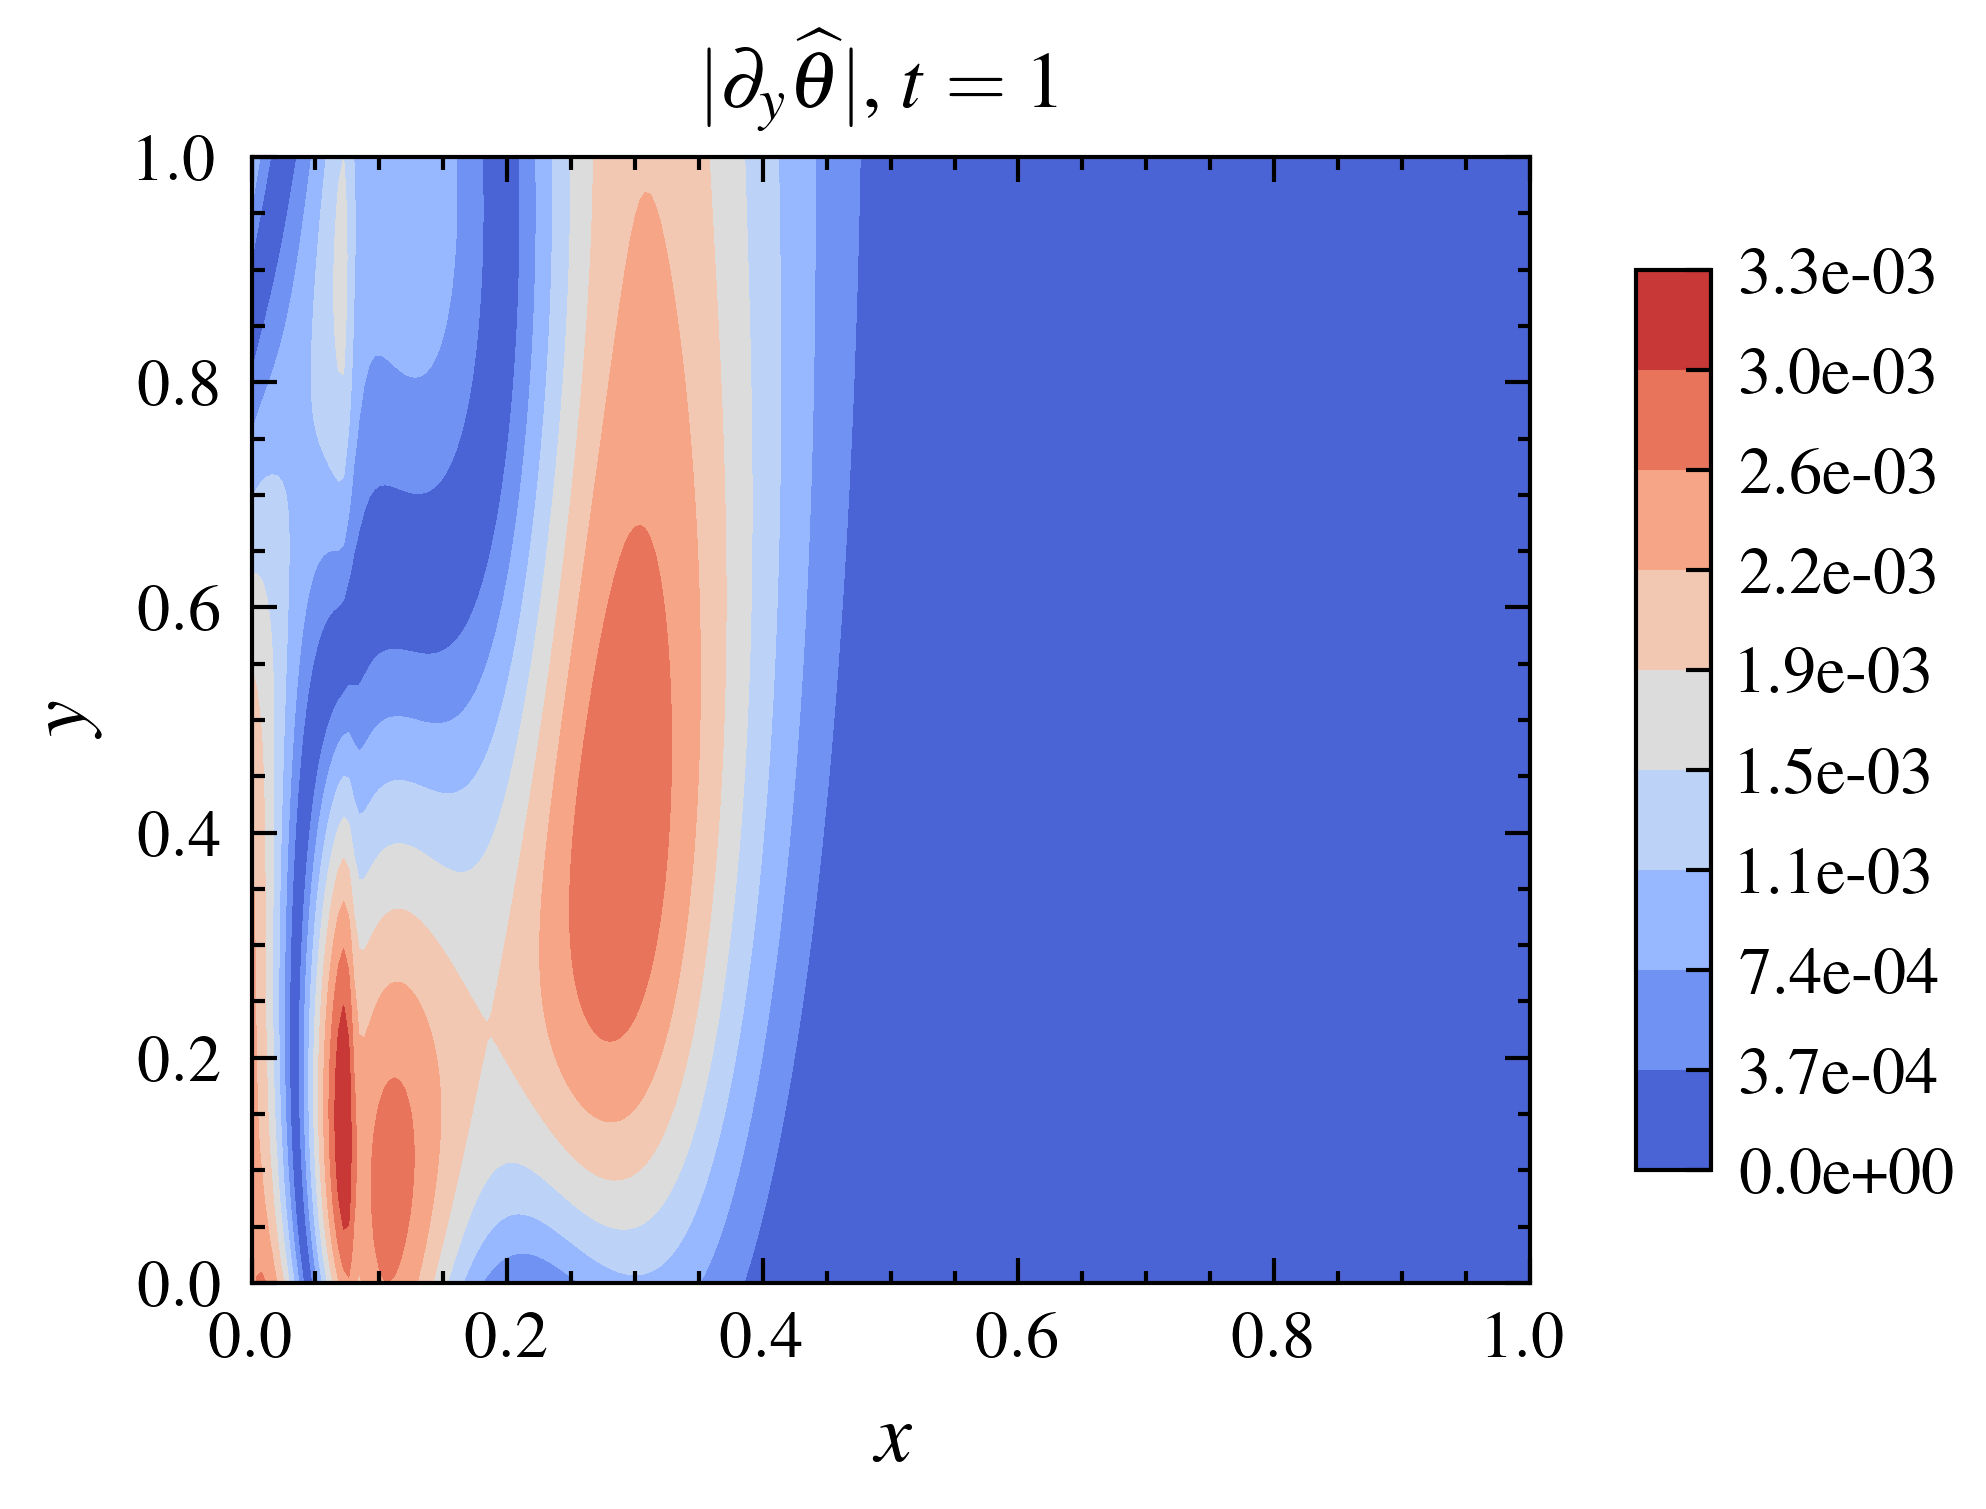

In [53]:
fig, axs = plt.subplots(1, 1, constrained_layout=True)

ctf = axs.contourf(x_grid, y_grid, np.abs(Ty), levels=levels, cmap=cmap)
cb = fig.colorbar(ctf, shrink=.8, aspect=12, ax = axs, format='%.1e')

axs.set_xlabel('$x$', fontsize = 10)
axs.set_ylabel('$y$', fontsize = 10)

axs.set_title(r"$t = 1$")
axs.set_title(r"$|\partial_y \widehat\theta|$, $t = 1$")

if save:
    plt.savefig(savefile+"2D1_dy.pdf")
    plt.savefig(savefile+"2D1_dy.png")
plt.show()

In [1]:
fig, axs = plt.subplots(1, 1, constrained_layout=True)

axs.grid(True)
axs.plot(x, np.diag(T_ref[0]), lw=2, c='red', alpha=.7, label=r'$\theta_\mathrm{ref}$, $t=0$')
axs.plot(x, np.diag(T_pred[0]), '--k', lw=2, alpha=.7, label=r'$\widehat\theta$, $t=0$')

axs.plot(x, np.diag(T_ref[-1]), '-b',lw=2, alpha=.7, label=r'$\theta_\mathrm{ref}$, $t=1$')
axs.plot(x, np.diag(T_pred[-1]), ':k', lw=3, alpha=.7, label=r'$\widehat\theta$, $t=1$')
axs.set_xlabel('$x$', fontsize = 10)
#axs.set_ylabel(r'$\theta$, $y = x$', fontsize = 10)

axs.set_title(r'Case 3. $\theta(x=y)$', fontsize=12)
axs.legend(loc='upper right', ncol=1, frameon=False)

if save:
    plt.savefig(savefile+"2D1_results_bis.pdf")
    plt.savefig(savefile+"2D1_results_bis.png")
plt.show()

NameError: name 'plt' is not defined